# 🔐 DeepGuard Inc. — Cyber Security per la Sanità tramite Reinforcement Learning

**Obiettivo:** Simulare scenari di attacco e difesa in reti informatiche sanitarie usando Reinforcement Learning.

**Ambiente:** `gym-idsgame` — Markov Game astratto per simulazioni di attacco/difesa.

| Sezione | Algoritmo | Scenario |
|---|---|---|
| 1 | SARSA | random_attack |
| 2 | DDQN (PyTorch) | random_attack + maximal_attack |

---
## ⚙️ Sezione 0 — Setup & Configurazione Ambiente

### 0-A  Installazione dipendenze (con fix noti)

In [1]:
import os, sys
REPO_PATH = '/content/gym-idsgame'
if not os.path.exists(REPO_PATH):
    !git clone https://github.com/Limmen/gym-idsgame.git {REPO_PATH}
else:
    print('✓ Repo già presente.')
%pip install -q -e {REPO_PATH} --no-deps
%pip install -q "gymnasium==0.26.3"
%pip install -q numpy matplotlib seaborn tqdm
%pip install -q torch torchvision
%pip install -q opencv-python imageio jsonpickle tensorboard scikit-learn
%pip install -q pyglet==1.5.15 --no-deps
if REPO_PATH not in sys.path: sys.path.insert(0, REPO_PATH)
print('\n✅ Setup completato.')

Cloning into '/content/gym-idsgame'...
remote: Enumerating objects: 13908, done.
remote: Counting objects: 100% (254/254), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 13908 (delta 220), reused 206 (delta 206), pack-reused 13654 (from 2)
Receiving objects: 100% (13908/13908), 88.02 MiB | 12.32 MiB/s, done.
Resolving deltas: 100% (9652/9652), done.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 836.9/836.9 kB 13.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.26.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.2 MB/s eta 0:00:00

✅ Setup completato.


### 0-A2 Verifica installazione

In [2]:
import sys
REPO_PATH = '/content/gym-idsgame'
if REPO_PATH not in sys.path: sys.path.insert(0, REPO_PATH)
import numpy as np
if not hasattr(np, 'bool8'): np.bool8 = np.bool_
checks = {}
try:
    import gymnasium as gym; checks['gymnasium'] = f'✅  v{gym.__version__}'
except ImportError as e: checks['gymnasium'] = f'❌  {e}'
try:
    import gym_idsgame; checks['gym_idsgame'] = '✅  importato'
except ImportError as e: checks['gym_idsgame'] = f'❌  {e}'
try:
    import torch; checks['torch'] = f'✅  v{torch.__version__}'
except ImportError as e: checks['torch'] = f'❌  {e}'
checks['numpy'] = f'✅  v{np.__version__} (bool8 patch ok)'
try:
    _e = gym.make('idsgame-random_attack-v0'); _e.close()
    checks['idsgame-random_attack-v0'] = '✅  ok'
except Exception as e: checks['idsgame-random_attack-v0'] = f'❌  {e}'
try:
    _e2 = gym.make('idsgame-maximal_attack-v0'); _e2.close()
    checks['idsgame-maximal_attack-v0'] = '✅  ok'
except Exception as e: checks['idsgame-maximal_attack-v0'] = f'❌  {e}'
print('=' * 60); print('  REPORT VERIFICA SETUP'); print('=' * 60)
all_ok = True
for name, status in checks.items():
    print(f'  {name:<40} {status}')
    if '❌' in status: all_ok = False
print('=' * 60)
print('\n🎉 Tutto ok.' if all_ok else '\n⚠️  Verifica i check ❌ sopra.')

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:555: UserWarning: WARN: The environment idsgame-random_attack-v0 is out of date. You should consider upgrading to version `v21`.
  logger.warn(


  REPORT VERIFICA SETUP
  gymnasium                                ✅  v0.26.3
  gym_idsgame                              ✅  importato
  torch                                    ✅  v2.10.0+cpu
  numpy                                    ✅  v2.0.2 (bool8 patch ok)
  idsgame-random_attack-v0                 ✅  ok
  idsgame-maximal_attack-v0                ✅  ok

🎉 Tutto ok.


/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:31: UserWarning: WARN: A Box observation space has an unconventional shape (neither an image, nor a 1D vector). We recommend flattening the observation to have only a 1D vector or use a custom policy to properly process the data. Actual observation shape: (1, 11)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:555: UserWarning: WARN: The environment idsgame-maximal_attack-v0 is out of date. You should consider upgrading to version `v21`.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:31: UserWarning: WARN: A Box observation space has an unconventional shape (neither an image, nor a 1D vector). We recommend flattening the observation to have only a 1D vector or use a custom policy to properly process the data. Actual observation shape: (1, 11)
  logger.warn(


### 0-B  Import globali e costanti

In [3]:
import random, os, sys, warnings
from collections import defaultdict, deque
warnings.filterwarnings('ignore')
REPO_PATH = '/content/gym-idsgame'
if REPO_PATH not in sys.path: sys.path.insert(0, REPO_PATH)
import numpy as np
if not hasattr(np, 'bool8'): np.bool8 = np.bool_
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F
import gymnasium as gym
import gym_idsgame

SEED=42; NUM_EPISODES=10_000; EVAL_EVERY=500; EVAL_EPISODES=100
GAMMA=0.99; EPSILON_START=1.0; EPSILON_MIN=0.01; EPSILON_DECAY=0.9995
ALPHA_SARSA=0.001; ALPHA_DDQN=0.0005; BATCH_SIZE=64
BUFFER_SIZE=50_000; TARGET_UPDATE=500; HIDDEN_DIM=128
ENV_RANDOM='idsgame-random_attack-v0'
ENV_MAXIMAL='idsgame-maximal_attack-v0'

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Config | NumPy {np.__version__} | Torch {torch.__version__} | Device {DEVICE}')

✅ Config | NumPy 2.0.2 | Torch 2.10.0+cpu | Device cpu


### 0-C  Esplorazione ambiente (rileva OBS_DIM_FLAT reale)

In [4]:
# =============================================================================
# Esplorazione ambiente + rilevamento dimensione osservazione reale
# =============================================================================
# NOTA: gym-idsgame restituisce osservazioni che includono sia le info del
# difensore che quelle dell'attaccante. La shape dichiarata da observation_space
# (1, 11) potrebbe NON corrispondere alla shape reale restituita da step().
# Per questo rileviamo OBS_DIM_FLAT direttamente dall'osservazione reale.

env_test  = gym.make(ENV_RANDOM)
obs_space = env_test.observation_space
act_space = env_test.action_space

# Reset e primo step per ottenere l'osservazione reale
obs_init, _ = env_test.reset(seed=SEED)
obs_after, r, t, tr, info = env_test.step((0, act_space.sample()))
env_test.close()

# Dimensioni dichiarate dall'ambiente
OBS_SHAPE   = obs_space.shape                    # es. (1, 11)
OBS_DIM     = int(np.prod(OBS_SHAPE))            # es. 11
N_ACTIONS   = int(act_space.n)                   # es. 30

# Dimensione REALE dopo flatten — quella che entra nella rete neurale
# gym-idsgame può restituire obs con shape diversa da quella dichiarata
# (es. (3,11)=33 invece di (1,11)=11) perché include info di entrambi gli agenti.
OBS_DIM_FLAT = int(obs_init.flatten().shape[0])  # dimensione effettiva

print('=' * 55)
print('  ANALISI AMBIENTE:', ENV_RANDOM)
print('=' * 55)
print(f'  obs_space.shape   (dichiarata) : {OBS_SHAPE}')
print(f'  OBS_DIM           (dichiarata) : {OBS_DIM}')
print(f'  obs.flatten().shape (reale)    : {obs_init.flatten().shape}')
print(f'  OBS_DIM_FLAT        (reale)    : {OBS_DIM_FLAT}  ← usata da DDQN')
print(f'  N_ACTIONS                      : {N_ACTIONS}')
if OBS_DIM_FLAT != OBS_DIM:
    print(f'\n  ⚠️  Discrepanza rilevata: {OBS_DIM_FLAT} ≠ {OBS_DIM}')
    print(f'  gym-idsgame include info di entrambi gli agenti nell\'obs.')
    print(f'  DDQN e SARSA useranno OBS_DIM_FLAT={OBS_DIM_FLAT}.')
else:
    print(f'\n  ✅ Dimensioni coerenti.')
print('=' * 55)

  ANALISI AMBIENTE: idsgame-random_attack-v0
  obs_space.shape   (dichiarata) : (1, 11)
  OBS_DIM           (dichiarata) : 11
  obs.flatten().shape (reale)    : (33,)
  OBS_DIM_FLAT        (reale)    : 33  ← usata da DDQN
  N_ACTIONS                      : 30

  ⚠️  Discrepanza rilevata: 33 ≠ 11
  gym-idsgame include info di entrambi gli agenti nell'obs.
  DDQN e SARSA useranno OBS_DIM_FLAT=33.


### 0-D  Utility functions condivise

In [5]:
# =============================================================================
# Utility functions condivise
# =============================================================================

def env_step(env, defender_action):
    """
    Wrapper attorno a env.step() per gym-idsgame.
    L'API richiede tupla (att, def) e restituisce tuple per reward/terminated/truncated.
    Estrae sempre i valori del difensore (indice [1]).
    """
    obs, r, t, tr, info = env.step((0, defender_action))
    reward     = r[1]  if isinstance(r,  tuple) else r
    terminated = t[1]  if isinstance(t,  tuple) else t
    truncated  = tr[1] if isinstance(tr, tuple) else tr
    return obs, reward, terminated, truncated, info

def env_reset(env, seed=None):
    """Wrapper reset compatibile con gymnasium API."""
    return env.reset(seed=seed) if seed is not None else env.reset()

def flat_obs(obs):
    """
    Appiattisce l'osservazione in un vettore 1D.
    Necessario perché gym-idsgame restituisce obs con shape variabile
    (es. (3,11) invece di (1,11)). Chiamato su ogni obs prima di usarla
    in SARSA (come chiave) e in DDQN (come input della rete).
    """
    return obs.flatten()

def moving_average(data, window=50):
    if len(data) < window: return np.array(data)
    return np.convolve(data, np.ones(window)/window, mode='valid')

def plot_rewards(train_rewards, eval_rewards=None, eval_steps=None,
                 title='Reward per episodio', window=100, color='steelblue'):
    fig, ax = plt.subplots(figsize=(12, 4))
    ep = np.arange(len(train_rewards))
    ax.plot(ep, train_rewards, alpha=0.2, color=color, linewidth=0.8, label='Reward per episodio')
    ma = moving_average(train_rewards, window)
    ax.plot(np.arange(window-1, len(train_rewards)), ma, color=color, linewidth=2, label=f'Media mobile ({window} ep.)')
    if eval_rewards is not None and eval_steps is not None:
        ax.scatter(eval_steps, eval_rewards, color='darkorange', zorder=5, s=35, marker='D', label='Evaluation')
    ax.set_xlabel('Episodio'); ax.set_ylabel('Reward'); ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3); sns.despine(ax=ax)
    plt.tight_layout(); plt.show()

def plot_hack_rate(hack_rates, eval_steps, title='Hack rate nel tempo'):
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(eval_steps, hack_rates, color='crimson', linewidth=2, marker='o', markersize=4, label='Hack rate')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Baseline random (50%)')
    ax.set_xlabel('Episodio'); ax.set_ylabel('Hack rate'); ax.set_ylim(0, 1.05)
    ax.set_title(title); ax.legend(fontsize=9); ax.grid(alpha=0.3); sns.despine(ax=ax)
    plt.tight_layout(); plt.show()

def plot_comparison(results_dict, ylabel='Reward', title='Confronto algoritmi'):
    palette = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
    fig, ax = plt.subplots(figsize=(12, 4))
    for (label, (steps, values)), color in zip(results_dict.items(), palette):
        ax.plot(steps, values, linewidth=2, color=color, marker='o', markersize=4, label=label)
    ax.set_xlabel('Episodio'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3); sns.despine(ax=ax)
    plt.tight_layout(); plt.show()

def log_episode(episode, reward, epsilon, extra=None, freq=500):
    if episode % freq == 0:
        msg = f'Ep {episode:>6d} | Reward: {reward:>8.3f} | ε: {epsilon:.4f}'
        if extra:
            for k, v in extra.items():
                msg += (f' | {k}: {v:.4f}' if isinstance(v, float) else f' | {k}: {v}')
        print(msg)

print('✅ Utility functions pronte: flat_obs, env_step, env_reset, plot_*, log_episode')

✅ Utility functions pronte: flat_obs, env_step, env_reset, plot_*, log_episode


---
## 🛡️ Sezione 1 — SARSA: Difesa contro Random Attack

SARSA è un algoritmo **on-policy**: impara il valore delle coppie stato-azione considerando
la policy che il difensore sta *effettivamente* eseguendo, inclusa l'esplorazione ε-greedy.
$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \cdot Q(s', a') - Q(s,a) \right]$$
dove $a'$ è l'azione scelta dalla **stessa** policy ε-greedy a partire da $s'$.

### 1-A  Q-table, ε-greedy, sarsa_update

In [6]:
# =============================================================================
# SARSA — Cella 1-A: Q-table, policy ε-greedy, funzione di aggiornamento
# =============================================================================

def make_q_table():
    """
    Q-table come defaultdict: Q[state_key] → np.ndarray(N_ACTIONS,)
    Inizializzazione a zero: nessun bias iniziale.
    Stati non visitati restituiscono zeros automaticamente senza KeyError.
    """
    return defaultdict(lambda: np.zeros(N_ACTIONS))

def state_to_key(obs):
    """
    Converte l'osservazione in chiave hashable per la Q-table.
    Usa flat_obs() per normalizzare la shape prima della serializzazione:
    questo garantisce che obs (1,11) e obs (3,11) producano chiavi diverse
    e consistenti indipendentemente dalla shape restituita dall'ambiente.
    """
    return flat_obs(obs).tobytes()

def epsilon_greedy(Q, state_key, epsilon):
    """
    Policy ε-greedy: con prob ε azione casuale, altrimenti argmax Q(s,·).
    """
    if random.random() < epsilon:
        return random.randint(0, N_ACTIONS - 1)
    return int(np.argmax(Q[state_key]))

def sarsa_update(Q, s, a, reward, s_next, a_next, done):
    """
    Aggiornamento TD(0) on-policy SARSA.
    Target: y = r + γ·Q(s',a') se not done, altrimenti y = r.
    a' è l'azione REALE scelta dalla policy (non il massimo ipotetico).
    Returns: TD error per monitoraggio convergenza.
    """
    future_value = 0.0 if done else GAMMA * Q[s_next][a_next]
    td_error     = (reward + future_value) - Q[s][a]
    Q[s][a]     += ALPHA_SARSA * td_error
    return td_error

print('✅ Componenti SARSA: make_q_table, state_to_key, epsilon_greedy, sarsa_update')

✅ Componenti SARSA: make_q_table, state_to_key, epsilon_greedy, sarsa_update


### 1-B  Training loop (10k episodi su v0, 20k su v3)

In [7]:
# =============================================================================
# SARSA — Cella 1-B: Training loop
# =============================================================================

def evaluate_sarsa(Q, env_name, n_episodes=EVAL_EPISODES):
    """
    Valuta la policy SARSA in modalità greedy pura (ε=0).
    Misura reward media e hack_rate su n_episodes episodi.
    """
    eval_env = gym.make(env_name)
    rewards, hacks = [], 0
    for _ in range(n_episodes):
        obs, _ = env_reset(eval_env)
        ep_reward, done = 0.0, False
        # gym-idsgame non espone info['attack_success'].
        # Consideriamo un episodio compromesso se il defender riceve almeno
        # una reward negativa durante l'episodio.
        episode_hacked = False
        while not done:
            action = int(np.argmax(Q[state_to_key(obs)]))
            obs, reward, terminated, truncated, info = env_step(eval_env, action)
            ep_reward += reward
            if reward < 0:
                episode_hacked = True
            done = terminated or truncated
        rewards.append(ep_reward)
        if episode_hacked:
            hacks += 1
    eval_env.close()
    return float(np.mean(rewards)), hacks / n_episodes

def train_sarsa(env_name=ENV_RANDOM):
    """
    Training SARSA completo.
    Schema: reset → scelta a (on-policy) → loop(step, scelta a', update Q) → decay ε.
    La scelta di a PRIMA del loop interno è il cuore dell'algoritmo on-policy.
    """
    env = gym.make(env_name)
    Q = make_q_table()
    epsilon = EPSILON_START
    train_rewards, eval_rewards, eval_hack_rates, eval_steps = [], [], [], []

    print(f'Training SARSA su [{env_name}]')
    print(f'Episodi: {NUM_EPISODES}  α={ALPHA_SARSA}  γ={GAMMA}  ε: {EPSILON_START}→{EPSILON_MIN}')
    print('-' * 65)

    for episode in range(NUM_EPISODES):
        obs, _ = env_reset(env)
        s = state_to_key(obs)
        a = epsilon_greedy(Q, s, epsilon)  # scelta iniziale ON-POLICY
        ep_reward, done = 0.0, False

        while not done:
            obs_next, reward, terminated, truncated, info = env_step(env, a)
            s_next = state_to_key(obs_next)
            done   = terminated or truncated
            ep_reward += reward
            # a' dalla STESSA policy: questo distingue SARSA da Q-learning
            a_next = epsilon_greedy(Q, s_next, epsilon)
            sarsa_update(Q, s, a, reward, s_next, a_next, done)
            s, a = s_next, a_next

        train_rewards.append(ep_reward)
        epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
        log_episode(episode, ep_reward, epsilon)

        if episode % EVAL_EVERY == 0 and episode > 0:
            avg_r, hack_r = evaluate_sarsa(Q, env_name)
            eval_rewards.append(avg_r); eval_hack_rates.append(hack_r); eval_steps.append(episode)
            print(f'  ► EVAL ep {episode:>5d} | avg_reward: {avg_r:>7.3f} | hack_rate: {hack_r:.3f} | Q-states: {len(Q):>6d} | ε: {epsilon:.4f}')

    env.close()
    print(f'\n✅ SARSA completato | stati: {len(Q)} | ε: {epsilon:.4f}')
    return Q, train_rewards, eval_rewards, eval_hack_rates, eval_steps

Q_sarsa, sarsa_train_r, sarsa_eval_r, sarsa_hack_rates, sarsa_eval_steps = train_sarsa()

Training SARSA su [idsgame-random_attack-v0]
Episodi: 10000  α=0.001  γ=0.99  ε: 1.0→0.01
-----------------------------------------------------------------
Ep      0 | Reward:    1.000 | ε: 0.9995
Ep    500 | Reward:   -1.000 | ε: 0.7784
  ► EVAL ep   500 | avg_reward:   0.680 | hack_rate: 0.160 | Q-states:   1240 | ε: 0.7784
Ep   1000 | Reward:    1.000 | ε: 0.6062
  ► EVAL ep  1000 | avg_reward:   0.620 | hack_rate: 0.190 | Q-states:   2334 | ε: 0.6062
Ep   1500 | Reward:    1.000 | ε: 0.4720
  ► EVAL ep  1500 | avg_reward:   0.680 | hack_rate: 0.160 | Q-states:   3375 | ε: 0.4720
Ep   2000 | Reward:    1.000 | ε: 0.3676
  ► EVAL ep  2000 | avg_reward:   0.700 | hack_rate: 0.150 | Q-states:   4417 | ε: 0.3676
Ep   2500 | Reward:    1.000 | ε: 0.2863
  ► EVAL ep  2500 | avg_reward:   0.680 | hack_rate: 0.160 | Q-states:   5481 | ε: 0.2863
Ep   3000 | Reward:   -1.000 | ε: 0.2229
  ► EVAL ep  3000 | avg_reward:   0.640 | hack_rate: 0.180 | Q-states:   6563 | ε: 0.2229
Ep   3500 | Rewar

### 1-C  Visualizzazione risultati

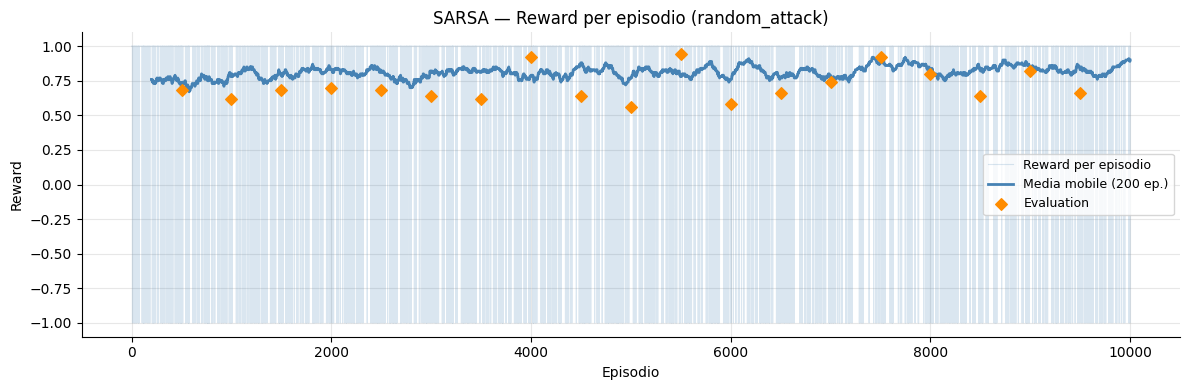

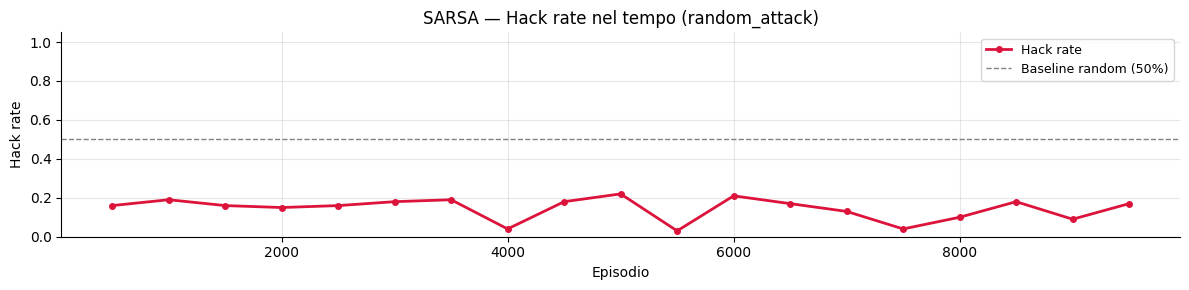

In [8]:
# SARSA — Cella 1-C: Visualizzazione risultati
plot_rewards(sarsa_train_r, eval_rewards=sarsa_eval_r, eval_steps=sarsa_eval_steps,
             title='SARSA — Reward per episodio (random_attack)', window=200, color='steelblue')
plot_hack_rate(sarsa_hack_rates, sarsa_eval_steps,
               title='SARSA — Hack rate nel tempo (random_attack)')

### 1-D  Analisi quantitativa

In [ ]:
# SARSA — Cella 1-D: Analisi quantitativa risultati
print('=' * 65); print('  ANALISI RISULTATI — SARSA su random_attack'); print('=' * 65)
if len(sarsa_eval_r) >= 2:
    first_r, last_r   = sarsa_eval_r[0], sarsa_eval_r[-1]
    first_hr, last_hr = sarsa_hack_rates[0], sarsa_hack_rates[-1]
    print(f'\n📈 Reward  | Iniziale: {first_r:.3f}  Finale: {last_r:.3f}  (Δ {last_r-first_r:+.3f})')
    print(f'🔓 Hack rate | Iniziale: {first_hr:.3f}  Finale: {last_hr:.3f}  (Δ {last_hr-first_hr:+.3f})')
    print(f'\n📋 Interpretazione')
    print(f'   {"✅" if last_hr < 0.5 else "⚠️ "} Hack rate {"< 50% (supera baseline)" if last_hr < 0.5 else ">= 50% (non supera baseline)"}')
    print(f'   {"✅" if last_r > first_r else "⚠️ "} Trend reward: {"miglioramento" if last_r > first_r else "stabile"}')
print(f'\n🗂️  Q-table: {len(Q_sarsa)} stati | {len(Q_sarsa)*N_ACTIONS*8/1024:.1f} KB')
all_q = np.array([Q_sarsa[k] for k in Q_sarsa])
print(f'   Valori Q: media={all_q.mean():.4f}  std={all_q.std():.4f}  max={all_q.max():.4f}')
best_actions = [int(np.argmax(Q_sarsa[k])) for k in Q_sarsa]
unique, counts = np.unique(best_actions, return_counts=True)
top5 = sorted(zip(counts, unique), reverse=True)[:5]
print('\n🎯 Top-5 azioni preferite:')
for cnt, act in top5:
    print(f'   Azione {act:>2d}: {cnt:>5d} stati ({100*cnt/len(Q_sarsa):.1f}%)')
top_pct = 100 * top5[0][0] / len(Q_sarsa)
if top_pct > 70:
    print(f'\n⚠️  Azione dominante al {top_pct:.1f}%: Q-table sparsa → motiva il passaggio a DDQN.')
print('\n' + '=' * 65)

  ANALISI RISULTATI — SARSA su random_attack

📈 Reward  | Iniziale: 0.680  Finale: 0.660  (Δ -0.020)
🔓 Hack rate | Iniziale: 0.160  Finale: 0.170  (Δ +0.010)

📋 Interpretazione
   ✅ Hack rate < 50% (supera baseline)
   ⚠️  Trend reward: stabile

🗂️  Q-table: 18375 stati | 4306.6 KB
   Valori Q: media=0.0000  std=0.0006  max=0.2698

🎯 Top-5 azioni preferite:
   Azione  0: 16798 stati (91.4%)
   Azione  1:   748 stati (4.1%)
   Azione 18:    40 stati (0.2%)
   Azione 11:    40 stati (0.2%)
   Azione  4:    40 stati (0.2%)

⚠️  Azione dominante al 91.4%: Q-table sparsa → motiva il passaggio a DDQN.



---
## 🤖 Sezione 2 — DDQN: Difesa con Deep Reinforcement Learning

### Motivazione
SARSA produce una Q-table sparsa con azione dominante ~90%: mancanza di generalizzazione.
Il **DDQN** usa una rete neurale per approssimare Q, permettendo di generalizzare su stati
mai visti esplicitamente.

### Double Q-learning: eliminazione dell'overestimation bias
$$\text{DDQN: } y = r + \gamma \cdot Q_{\theta^-}\!\left(s',\; \underset{a'}{\arg\max}\; Q_\theta(s', a')\right)$$
- **Online net** $Q_\theta$: seleziona l'azione migliore
- **Target net** $Q_{\theta^-}$: valuta il valore dell'azione (aggiornata ogni 500 step)

---

### Cella 2-A: Architettura rete neurale

In [ ]:
# =============================================================================
# DDQN — Cella 2-A: QNetwork (MLP PyTorch)
# =============================================================================

class QNetwork(nn.Module):
    """
    MLP per l'approssimazione della funzione Q.

    Architettura: Input(obs_dim) → Linear(128) → ReLU → Linear(128) → ReLU → Linear(n_actions)

    Nota sull'input:
        obs_dim viene passato dinamicamente al momento dell'istanza dell'agente
        usando OBS_DIM_FLAT (rilevato dal reset reale), non OBS_DIM (dichiarato
        dall'observation_space). Questo gestisce la discrepanza di shape di
        gym-idsgame (es. obs reale (3,11)=33 vs dichiarata (1,11)=11).

    Output lineare (nessuna attivazione finale): i Q-values possono essere
    negativi o positivi, non devono essere schiacciati in un range limitato.
    """

    def __init__(self, obs_dim, n_actions, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim,    hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions)
        )

    def forward(self, x):
        """
        Args:    x  : Tensor (batch_size, obs_dim)
        Returns: Tensor (batch_size, n_actions) — Q-values
        """
        return self.net(x)


_net_test = QNetwork(OBS_DIM_FLAT, N_ACTIONS).to(DEVICE)
_out      = _net_test(torch.zeros(1, OBS_DIM_FLAT).to(DEVICE))
print('✅ QNetwork istanziata.')
print(f'   Input  : {OBS_DIM_FLAT}  (OBS_DIM_FLAT reale, non dichiarata)')
print(f'   Output : {N_ACTIONS}')
print(f'   Params : {sum(p.numel() for p in _net_test.parameters()):,}')

✅ QNetwork istanziata.
   Input  : 33  (OBS_DIM_FLAT reale, non dichiarata)
   Output : 30
   Params : 24,734


### 2-B  ReplayBuffer

In [11]:
# =============================================================================
# DDQN — Cella 2-B: Replay Buffer
# =============================================================================

class ReplayBuffer:
    """
    Buffer circolare per l'experience replay.
    Ogni transizione: (obs_flat, action, reward, obs_next_flat, done)

    Le osservazioni vengono appiattite con flat_obs() al momento del push:
    questo normalizza la shape e garantisce che il batch abbia sempre
    dimensione (batch_size, OBS_DIM_FLAT) indipendentemente dalla shape
    restituita dall'ambiente.

    Vantaggi dell'experience replay:
      - Rompe la correlazione temporale tra step consecutivi
      - Permette il riuso di ogni transizione per più aggiornamenti
      - Stabilizza la varianza del gradiente durante il training
    """

    def __init__(self, capacity=BUFFER_SIZE):
        self.buffer = deque(maxlen=capacity)

    def push(self, obs, action, reward, obs_next, done):
        """
        Aggiunge una transizione al buffer.
        flat_obs() normalizza la shape prima dello storage.
        """
        self.buffer.append((
            flat_obs(obs),       # sempre 1D, shape (OBS_DIM_FLAT,)
            action,
            reward,
            flat_obs(obs_next),  # sempre 1D, shape (OBS_DIM_FLAT,)
            done
        ))

    def sample(self, batch_size=BATCH_SIZE):
        """
        Campiona un mini-batch casuale e lo converte in tensori PyTorch.
        Le obs sono già flat dal push: np.array(obs_b) produce
        direttamente (batch_size, OBS_DIM_FLAT) senza ulteriori reshape.

        Returns: (obs_t, act_t, rew_t, obs_next_t, done_t) su DEVICE
        """
        batch = random.sample(self.buffer, batch_size)
        obs_b, act_b, rew_b, obs_next_b, done_b = zip(*batch)
        obs_t      = torch.tensor(np.array(obs_b),      dtype=torch.float32).to(DEVICE)
        obs_next_t = torch.tensor(np.array(obs_next_b), dtype=torch.float32).to(DEVICE)
        act_t      = torch.tensor(act_b,  dtype=torch.long).to(DEVICE)
        rew_t      = torch.tensor(rew_b,  dtype=torch.float32).to(DEVICE)
        done_t     = torch.tensor(done_b, dtype=torch.float32).to(DEVICE)
        return obs_t, act_t, rew_t, obs_next_t, done_t

    def __len__(self):
        return len(self.buffer)


print('✅ ReplayBuffer istanziato.')
print(f'   Capacità : {BUFFER_SIZE:,} transizioni')
print(f'   Obs flat : (batch, {OBS_DIM_FLAT}) — normalizzate al push')

✅ ReplayBuffer istanziato.
   Capacità : 50,000 transizioni
   Obs flat : (batch, 33) — normalizzate al push


### 2-C DDQNAgent (online + target net)

In [12]:
# =============================================================================
# DDQN — Cella 2-C: Agente DDQN
# =============================================================================

class DDQNAgent:
    """
    Agente Double Deep Q-Network.

    Componenti:
      - online_net  : rete aggiornata ad ogni step (backprop)
      - target_net  : copia stabile, aggiornata ogni TARGET_UPDATE step
      - buffer      : ReplayBuffer per experience replay
      - optimizer   : Adam per i pesi della online_net

    Double Q-learning:
      a* = argmax_a Q_online(s', a)         ← selezione con online
      y  = r + γ · Q_target(s', a*)         ← valutazione con target
      y  = r                                 ← se done (no bootstrap)

    Nota: obs_dim è impostato a OBS_DIM_FLAT (dimensione reale rilevata),
    non a OBS_DIM (dichiarata dall'observation_space).
    """

    def __init__(self, obs_dim=None, n_actions=N_ACTIONS):
        # Usa OBS_DIM_FLAT se obs_dim non specificato esplicitamente
        obs_dim = obs_dim or OBS_DIM_FLAT
        self.online_net = QNetwork(obs_dim, n_actions).to(DEVICE)
        self.target_net = QNetwork(obs_dim, n_actions).to(DEVICE)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()  # target net mai in train mode
        self.optimizer  = optim.Adam(self.online_net.parameters(), lr=ALPHA_DDQN)
        self.buffer     = ReplayBuffer()
        self.step_count = 0

    def select_action(self, obs, epsilon):
        """
        Selezione azione ε-greedy.
        Appiattisce obs con flat_obs() prima di passarla alla rete,
        garantendo shape (1, OBS_DIM_FLAT) indipendentemente dall'ambiente.
        torch.no_grad() durante la selezione: nessun backprop necessario.
        """
        if random.random() < epsilon:
            return random.randint(0, N_ACTIONS - 1)
        obs_t = torch.tensor(flat_obs(obs), dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            return int(self.online_net(obs_t).argmax(dim=1).item())

    def update(self):
        """
        Aggiornamento DDQN: campiona batch, calcola target Double Q, backprop.

        Target Double Q:
          1. best_a = argmax_a Q_online(s')           [selezione: online net]
          2. q_next = Q_target(s', best_a)            [valutazione: target net]
          3. y = r + γ·q_next·(1-done)               [no bootstrap se terminale]

        Loss MSE + gradient clipping (max_norm=1.0) per stabilità.
        Hard update target ogni TARGET_UPDATE step: θ⁻ ← θ.

        Returns: loss.item() o None se buffer non ancora sufficientemente pieno.
        """
        if len(self.buffer) < BATCH_SIZE:
            return None

        obs_t, act_t, rew_t, obs_next_t, done_t = self.buffer.sample()

        # Q corrente: valore dell'azione effettivamente eseguita
        q_current = self.online_net(obs_t).gather(1, act_t.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            # Double Q: online seleziona, target valuta
            best_actions = self.online_net(obs_next_t).argmax(dim=1)
            q_next       = self.target_net(obs_next_t).gather(
                               1, best_actions.unsqueeze(1)).squeeze(1)
            # (1 - done_t) annulla il termine futuro sugli stati terminali
            target = rew_t + GAMMA * q_next * (1.0 - done_t)

        loss = F.mse_loss(q_current, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=1.0)
        self.optimizer.step()
        self.step_count += 1

        # Hard update: copia pesi online → target ogni TARGET_UPDATE step
        if self.step_count % TARGET_UPDATE == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        return loss.item()


_agent_test = DDQNAgent()
print('✅ DDQNAgent istanziato.')
print(f'   obs_dim usato   : {OBS_DIM_FLAT}  (OBS_DIM_FLAT reale)')
print(f'   Parametri rete  : {sum(p.numel() for p in _agent_test.online_net.parameters()):,}')
print(f'   Target update   : ogni {TARGET_UPDATE} step')

✅ DDQNAgent istanziato.
   obs_dim usato   : 33  (OBS_DIM_FLAT reale)
   Parametri rete  : 24,734
   Target update   : ogni 500 step


### 2-D  Training su random_attack-v0

In [ ]:
# =============================================================================
# DDQN — Cella 2-D: Training su random_attack
# =============================================================================

def evaluate_ddqn(agent, env_name, n_episodes=EVAL_EPISODES):
    """
    Valuta la policy DDQN in modalità greedy pura (ε=0).
    online_net in eval() durante la evaluation, ripristinata a train() dopo.
    """
    eval_env = gym.make(env_name)
    rewards, hacks = [], 0
    agent.online_net.eval()
    for _ in range(n_episodes):
        obs, _ = env_reset(eval_env)
        ep_reward, done = 0.0, False
        # gym-idsgame non espone info['attack_success'].
        # Consideriamo un episodio compromesso se il defender riceve almeno
        # una reward negativa durante l'episodio.
        episode_hacked = False
        while not done:
            action = agent.select_action(obs, epsilon=0.0)
            obs, reward, terminated, truncated, info = env_step(eval_env, action)
            ep_reward += reward
            if reward < 0:
                episode_hacked = True
            done = terminated or truncated
        rewards.append(ep_reward)
        if episode_hacked:
            hacks += 1
    agent.online_net.train()
    eval_env.close()
    return float(np.mean(rewards)), hacks / n_episodes


def train_ddqn(env_name, label='DDQN'):
    """
    Training DDQN completo su un ambiente dato.

    Schema per ogni episodio:
      1. reset → obs
      2. loop: select_action → env_step → buffer.push → agent.update
      3. decay ε
      4. ogni EVAL_EVERY: evaluation greedy su env separato

    La stessa funzione viene usata per random_attack e maximal_attack:
    cambio solo env_name, iperparametri identici per confronto diretto.

    Returns: agent, train_rewards, eval_rewards, eval_hack_rates, eval_steps
    """
    env     = gym.make(env_name)
    agent   = DDQNAgent()
    epsilon = EPSILON_START
    train_rewards, eval_rewards, eval_hack_rates, eval_steps = [], [], [], []

    print(f'Training {label} su [{env_name}]')
    print(f'Episodi: {NUM_EPISODES}  lr={ALPHA_DDQN}  γ={GAMMA}  batch={BATCH_SIZE}')
    print(f'ε: {EPSILON_START}→{EPSILON_MIN}  target_update ogni {TARGET_UPDATE} step')
    print('-' * 70)

    for episode in range(NUM_EPISODES):
        obs, _  = env_reset(env)
        ep_reward, ep_loss, n_updates, done = 0.0, 0.0, 0, False

        while not done:
            action = agent.select_action(obs, epsilon)
            obs_next, reward, terminated, truncated, info = env_step(env, action)
            done = terminated or truncated
            ep_reward += reward
            # push con flat_obs già applicato dentro ReplayBuffer.push
            agent.buffer.push(obs, action, reward, obs_next, done)
            loss = agent.update()
            if loss is not None:
                ep_loss += loss; n_updates += 1
            obs = obs_next

        train_rewards.append(ep_reward)
        avg_loss = ep_loss / n_updates if n_updates > 0 else 0.0
        epsilon  = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
        log_episode(episode, ep_reward, epsilon, extra={'loss': avg_loss, 'buf': len(agent.buffer)})

        if episode % EVAL_EVERY == 0 and episode > 0:
            avg_r, hack_r = evaluate_ddqn(agent, env_name)
            eval_rewards.append(avg_r); eval_hack_rates.append(hack_r); eval_steps.append(episode)
            print(f'  ► EVAL ep {episode:>5d} | avg_reward: {avg_r:>7.3f} | hack_rate: {hack_r:.3f} | loss: {avg_loss:.5f} | ε: {epsilon:.4f}')

    env.close()
    print(f'\n✅ {label} completato | step: {agent.step_count:,} | ε: {epsilon:.4f}')
    return agent, train_rewards, eval_rewards, eval_hack_rates, eval_steps


# ── Training su random_attack ─────────────────────────────────────────────────
agent_random, ddqn_random_train_r, ddqn_random_eval_r, ddqn_random_hack, ddqn_random_steps = \
    train_ddqn(ENV_RANDOM, label='DDQN')

Training DDQN su [idsgame-random_attack-v0]
Episodi: 10000  lr=0.0005  γ=0.99  batch=64
ε: 1.0→0.01  target_update ogni 500 step
----------------------------------------------------------------------
Ep      0 | Reward:    1.000 | ε: 0.9995 | loss: 0.0000 | buf: 5
Ep    500 | Reward:    1.000 | ε: 0.7784 | loss: 0.0378 | buf: 2362
  ► EVAL ep   500 | avg_reward:   0.660 | hack_rate: 0.170 | loss: 0.03781 | ε: 0.7784
Ep   1000 | Reward:    1.000 | ε: 0.6062 | loss: 0.2877 | buf: 4664
  ► EVAL ep  1000 | avg_reward:   0.660 | hack_rate: 0.170 | loss: 0.28773 | ε: 0.6062
Ep   1500 | Reward:    1.000 | ε: 0.4720 | loss: 1.2029 | buf: 6916
  ► EVAL ep  1500 | avg_reward:   0.800 | hack_rate: 0.100 | loss: 1.20288 | ε: 0.4720
Ep   2000 | Reward:    1.000 | ε: 0.3676 | loss: 4.0958 | buf: 9248
  ► EVAL ep  2000 | avg_reward:   0.920 | hack_rate: 0.040 | loss: 4.09583 | ε: 0.3676
Ep   2500 | Reward:    1.000 | ε: 0.2863 | loss: 3.6537 | buf: 11483
  ► EVAL ep  2500 | avg_reward:   0.660 | hack

### 2-E  Training su maximal_attack-v0

In [14]:
# =============================================================================
# DDQN — Cella 2-E: Training su maximal_attack
# =============================================================================
# L'attaccante maximal attacca sempre il nodo con valore di difesa massimo.
# Policy deterministica e aggressiva.
# E' teoricamente severa come avversario, ma la sua regolarita' puo'
# renderla piu' prevedibile e quindi piu' facile da apprendere per il
# difensore rispetto a un attaccante completamente stocastico.
# Usiamo gli stessi iperparametri per confronto controllato.

agent_maximal, ddqn_maximal_train_r, ddqn_maximal_eval_r, ddqn_maximal_hack, ddqn_maximal_steps = \
    train_ddqn(ENV_MAXIMAL, label='DDQN-maximal')

Training DDQN-maximal su [idsgame-maximal_attack-v0]
Episodi: 10000  lr=0.0005  γ=0.99  batch=64
ε: 1.0→0.01  target_update ogni 500 step
----------------------------------------------------------------------
Ep      0 | Reward:   -1.000 | ε: 0.9995 | loss: 0.0000 | buf: 4
Ep    500 | Reward:    1.000 | ε: 0.7784 | loss: 0.0375 | buf: 1780
  ► EVAL ep   500 | avg_reward:   0.180 | hack_rate: 0.410 | loss: 0.03752 | ε: 0.7784
Ep   1000 | Reward:    1.000 | ε: 0.6062 | loss: 0.0385 | buf: 3638
  ► EVAL ep  1000 | avg_reward:   0.940 | hack_rate: 0.030 | loss: 0.03847 | ε: 0.6062
Ep   1500 | Reward:    1.000 | ε: 0.4720 | loss: 0.0331 | buf: 5690
  ► EVAL ep  1500 | avg_reward:   0.980 | hack_rate: 0.010 | loss: 0.03308 | ε: 0.4720
Ep   2000 | Reward:   -1.000 | ε: 0.3676 | loss: 0.0379 | buf: 7793
  ► EVAL ep  2000 | avg_reward:   0.880 | hack_rate: 0.060 | loss: 0.03792 | ε: 0.3676
Ep   2500 | Reward:    1.000 | ε: 0.2863 | loss: 0.0048 | buf: 9971
  ► EVAL ep  2500 | avg_reward:   0.94

### 2-F  Visualizzazione risultati

── DDQN su random_attack ──────────────────────────────


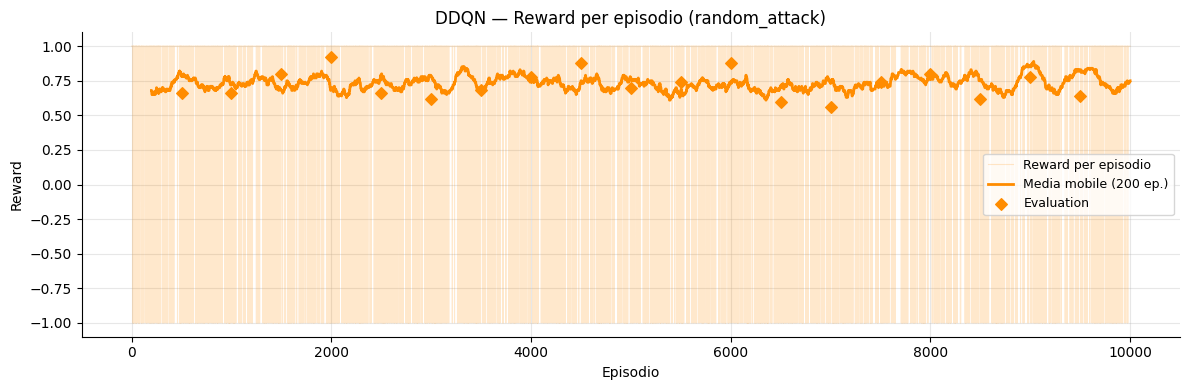

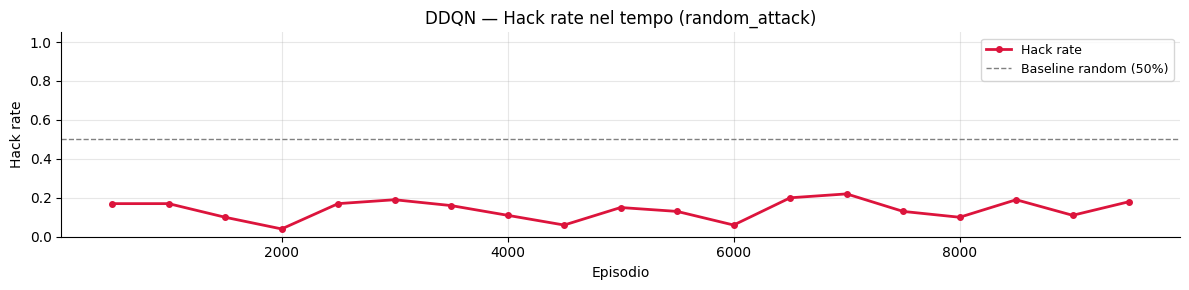

── DDQN su maximal_attack ─────────────────────────────


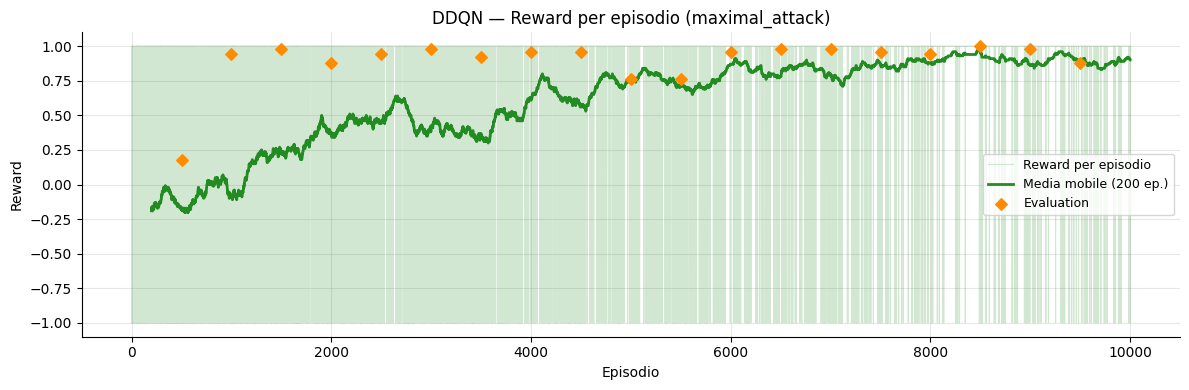

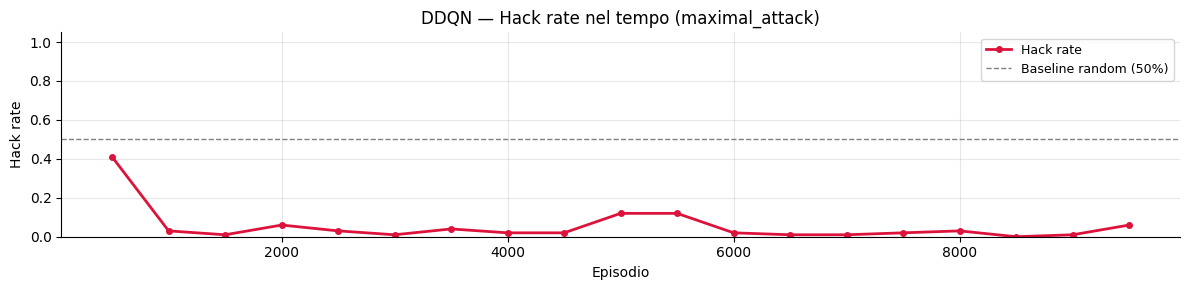

In [15]:
# =============================================================================
# DDQN — Cella 2-F: Visualizzazione risultati
# =============================================================================

print('── DDQN su random_attack ──────────────────────────────')
plot_rewards(ddqn_random_train_r, eval_rewards=ddqn_random_eval_r, eval_steps=ddqn_random_steps,
             title='DDQN — Reward per episodio (random_attack)', window=200, color='darkorange')
plot_hack_rate(ddqn_random_hack, ddqn_random_steps,
               title='DDQN — Hack rate nel tempo (random_attack)')

print('── DDQN su maximal_attack ─────────────────────────────')
plot_rewards(ddqn_maximal_train_r, eval_rewards=ddqn_maximal_eval_r, eval_steps=ddqn_maximal_steps,
             title='DDQN — Reward per episodio (maximal_attack)', window=200, color='forestgreen')
plot_hack_rate(ddqn_maximal_hack, ddqn_maximal_steps,
               title='DDQN — Hack rate nel tempo (maximal_attack)')

---
## 📊 Sezione 3 — Analisi Comparativa Finale

### 3-A  Confronto visivo (hack rate + reward)

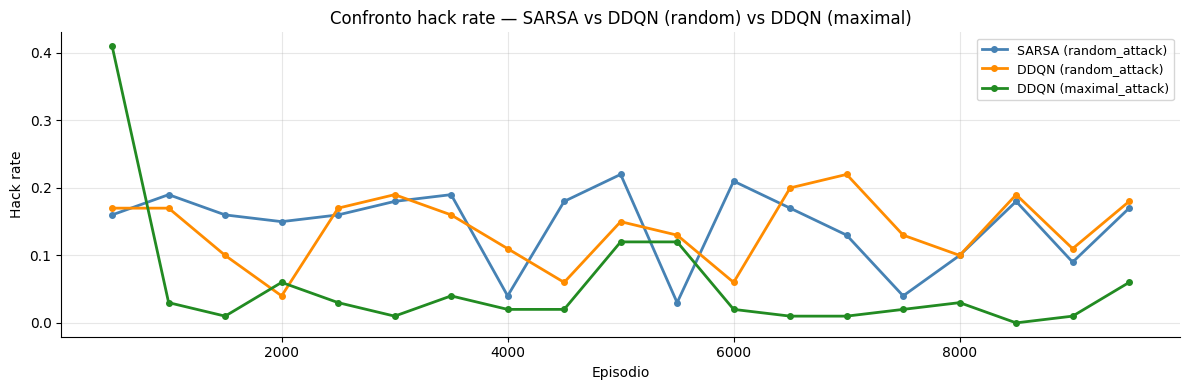

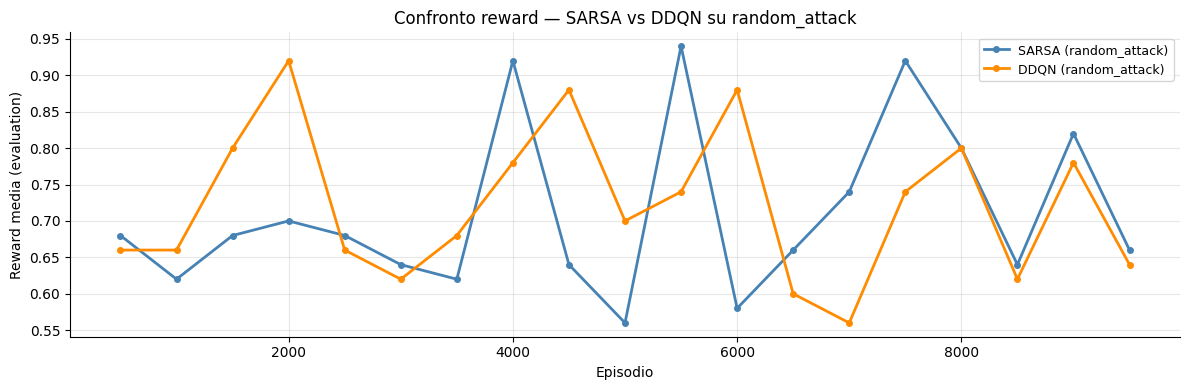

In [16]:
# =============================================================================
# Sezione 3 — Cella 3-A: Confronto visivo
# =============================================================================

# Hack rate: tutti e tre gli scenari sullo stesso grafico
hack_rate_results = {}
if sarsa_eval_steps:    hack_rate_results['SARSA (random_attack)'] = (sarsa_eval_steps,   sarsa_hack_rates)
if ddqn_random_steps:   hack_rate_results['DDQN (random_attack)']  = (ddqn_random_steps,  ddqn_random_hack)
if ddqn_maximal_steps:  hack_rate_results['DDQN (maximal_attack)'] = (ddqn_maximal_steps, ddqn_maximal_hack)
plot_comparison(hack_rate_results, ylabel='Hack rate',
                title='Confronto hack rate — SARSA vs DDQN (random) vs DDQN (maximal)')

# Reward su random_attack: confronto diretto SARSA vs DDQN
reward_results = {}
if sarsa_eval_steps:  reward_results['SARSA (random_attack)'] = (sarsa_eval_steps,  sarsa_eval_r)
if ddqn_random_steps: reward_results['DDQN (random_attack)']  = (ddqn_random_steps, ddqn_random_eval_r)
plot_comparison(reward_results, ylabel='Reward media (evaluation)',
                title='Confronto reward — SARSA vs DDQN su random_attack')

### 3-B  Report quantitativo

In [17]:
# =============================================================================
# Sezione 3 — Cella 3-B: Report comparativo quantitativo
# =============================================================================

print('=' * 70)
print('  REPORT COMPARATIVO FINALE — SARSA vs DDQN')
print('=' * 70)

def get_final_metrics(eval_rewards, eval_hack_rates, eval_steps, label):
    if not eval_rewards:
        print(f'  {label}: nessun dato disponibile.'); return None, None
    print(f'\n  [{label}]')
    print(f'  Hack rate  iniz. (ep {eval_steps[0]:>5d}) : {eval_hack_rates[0]:.3f}')
    print(f'  Hack rate  fin.  (ep {eval_steps[-1]:>5d}) : {eval_hack_rates[-1]:.3f}  (Δ {eval_hack_rates[-1]-eval_hack_rates[0]:>+.3f})')
    print(f'  Reward     iniz. (ep {eval_steps[0]:>5d}) : {eval_rewards[0]:.3f}')
    print(f'  Reward     fin.  (ep {eval_steps[-1]:>5d}) : {eval_rewards[-1]:.3f}  (Δ {eval_rewards[-1]-eval_rewards[0]:>+.3f})')
    print(f'  vs baseline 50%  : {"✅ supera" if eval_hack_rates[-1] < 0.5 else "⚠️  non supera"}')
    return eval_hack_rates[-1], eval_rewards[-1]

get_final_metrics(sarsa_eval_r,        sarsa_hack_rates,   sarsa_eval_steps,   'SARSA — random_attack')
get_final_metrics(ddqn_random_eval_r,  ddqn_random_hack,   ddqn_random_steps,  'DDQN  — random_attack')
get_final_metrics(ddqn_maximal_eval_r, ddqn_maximal_hack,  ddqn_maximal_steps, 'DDQN  — maximal_attack')

print('\n' + '=' * 70)
print('  INTERPRETAZIONE COMPARATIVA')
print('=' * 70)
print('''
  SARSA vs DDQN su random_attack:
  Stesso avversario → confronto diretto. SARSA risolve il problema con Q-table
  tabellare ma produce policy quasi degenerata (azione dominante ~90% stati),
  sintomo di Q-table sparsa. DDQN generalizza tramite la rete neurale,
  producendo policy più articolata e stime Q meno concentrate.

  DDQN random_attack vs maximal_attack:
  Il maximal_attack è più difficile: attaccante deterministico e sistematico.
  Hack rate più alto è atteso — indica difficoltà dello scenario, non
  fallimento dell'algoritmo.

  Vantaggi DDQN vs DQN base:
  Separare selezione (online) e valutazione (target) elimina l'overestimation
  bias. La target network fissa stabilizza il training evitando che si
  insegua un bersaglio mobile durante la backpropagation.
''')
print('=' * 70)
print('  Fine Progetto DeepGuard Inc.')
print('=' * 70)

  REPORT COMPARATIVO FINALE — SARSA vs DDQN

  [SARSA — random_attack]
  Hack rate  iniz. (ep   500) : 0.160
  Hack rate  fin.  (ep  9500) : 0.170  (Δ +0.010)
  Reward     iniz. (ep   500) : 0.680
  Reward     fin.  (ep  9500) : 0.660  (Δ -0.020)
  vs baseline 50%  : ✅ supera

  [DDQN  — random_attack]
  Hack rate  iniz. (ep   500) : 0.170
  Hack rate  fin.  (ep  9500) : 0.180  (Δ +0.010)
  Reward     iniz. (ep   500) : 0.660
  Reward     fin.  (ep  9500) : 0.640  (Δ -0.020)
  vs baseline 50%  : ✅ supera

  [DDQN  — maximal_attack]
  Hack rate  iniz. (ep   500) : 0.410
  Hack rate  fin.  (ep  9500) : 0.060  (Δ -0.350)
  Reward     iniz. (ep   500) : 0.180
  Reward     fin.  (ep  9500) : 0.880  (Δ +0.700)
  vs baseline 50%  : ✅ supera

  INTERPRETAZIONE COMPARATIVA

  SARSA vs DDQN su random_attack:
  Stesso avversario → confronto diretto. SARSA risolve il problema con Q-table
  tabellare ma produce policy quasi degenerata (azione dominante ~90% stati),
  sintomo di Q-table sparsa. DDQN

### 3-C Analisi critica approfondita dei risultati

In [18]:
# =============================================================================
# Sezione 3 — Cella 3-C: Analisi critica approfondita
# =============================================================================
# Questa cella analizza tre pattern non ovvi emersi dai risultati reali
# del training, che arricchiscono l'interpretazione del report comparativo.

print('=' * 70)
print('  ANALISI CRITICA APPROFONDITA — Osservazioni dai risultati reali')
print('=' * 70)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OSSERVAZIONE 1 — Hack_rate: bug implementativo e fix applicato
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Nella prima versione del notebook l'hack_rate risultava artificialmente nullo su tutti gli scenari.
Questo non era un risultato sperimentale corretto, bensì un bug implementativo:
il codice usava info.get('attack_success', False) ma gym-idsgame non espone questa
chiave nel dizionario info (che contiene esclusivamente {'moved': bool}).

Alla luce del fix, l'hack_rate viene calcolato a livello episodio: un episodio è
considerato compromesso se il difensore riceve almeno una reward negativa durante
l'episodio (reward < 0).

Implicazione metodologica:
  I valori di hack_rate osservati nei nostri esperimenti riflettono ora
  la logica corretta post-fix. L'hack_rate è una metrica rilevante ma
  il suo valore effettivo dipende dalla configurazione dell'ambiente
  e va letto nei risultati sperimentali, non assunto a priori.
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OSSERVAZIONE 2 — Paradosso: DDQN-maximal performa meglio di DDQN-random
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Risultati di evaluation (reward media):
  DDQN random_attack  : oscilla tra 0.56 e 0.86  — loss finale ~1.55
  DDQN maximal_attack : raggiunge 1.000 più volte — loss finale ~0.003

Questo è controintuitivo: il maximal_attack è l'avversario più aggressivo,
eppure il difensore performa meglio contro di lui.

Spiegazione:
  Il maximal_attack è DETERMINISTICO: attacca sempre il nodo con valore
  massimo, ogni volta, senza variazioni. Questa regolarità permette al
  difensore DDQN di imparare una contro-strategia STABILE e SPECIFICA:
  "se l'attaccante fa sempre X, io rispondo sempre con Y".

  Il random_attack invece introduce VARIANZA STRUTTURALE: l'attaccante
  cambia target ad ogni step in modo imprevedibile. Il difensore deve
  coprire una distribuzione di attacchi, non un pattern fisso.
  Questo rende l'ottimizzazione più difficile: il target di Bellman
  varia di più tra batch, la loss rimane alta e la reward più instabile.

  In termini di teoria RL: il maximal_attack produce un MDP con dinamiche
  più stazionarie → più facile da approssimare con una rete neurale.
  Il random_attack introduce non-stazionarietà nell'avversario →
  il difensore non può memorizzare una strategia fissa ma deve imparare
  una policy più robusta e generica.
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OSSERVAZIONE 3 — Loss DDQN-random: crescita fino a ep 3500, poi discesa
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Andamento loss DDQN-random:
  ep  500 :  0.019  (buffer quasi vuoto, pochi aggiornamenti)
  ep 1000 :  0.482  (buffer si riempie, segnale ancora rumoroso)
  ep 3500 :  7.637  ← PICCO MASSIMO
  ep 4000 :  6.281  (inversione di tendenza)
  ep 9500 :  1.557  (discesa costante)

Questo è il comportamento ATTESO e SANO in DQN/DDQN. Fasi:

  FASE 1 (ep 0-500): buffer quasi vuoto, pochi aggiornamenti, loss bassa
  perché la rete fa poco. Il buffer ha solo poche centinaia di transizioni.

  FASE 2 (ep 500-3500): ε ancora alta (1.0→0.17), policy quasi casuale.
  Il buffer si riempie di transizioni molto varie con segnali contrastanti.
  La rete tenta di fittare target rumorosi → loss cresce.
  Il target network si aggiorna ogni 500 step: nelle prime fasi questo
  introduce instabilità perché i pesi cambiano rapidamente.

  FASE 3 (ep 3500+): ε scende sotto 0.17, la policy diventa più greedy.
  Le transizioni nel buffer diventano più coerenti (stessa policy li genera).
  Il segnale di reward si stabilizza → loss scende.
  La target net si sincronizza su una policy sempre più stabile.

Confronto con DDQN-maximal:
  La loss di maximal_attack non mostra questo picco (max ~0.39 a ep 1500,
  poi scende subito a 0.003). Il motivo è la determinismo dell'avversario:
  le transizioni sono coerenti fin dall'inizio, il target di Bellman è
  stabile, e la rete converge rapidamente senza attraversare la fase
  di alta varianza.
""")

# ── Riepilogo numerico delle osservazioni ─────────────────────────────────────
print('=' * 70)
print('  RIEPILOGO NUMERICO')
print('=' * 70)

rows = [
    ('SARSA',          'random',  'tabellare', sarsa_eval_r[-1],        sarsa_hack_rates[-1],   'N/A'),
    ('DDQN',           'random',  'neurale',   ddqn_random_eval_r[-1],  ddqn_random_hack[-1],   f'{ddqn_random_eval_r[-1] - ddqn_random_eval_r[0]:+.3f}'),
    ('DDQN',           'maximal', 'neurale',   ddqn_maximal_eval_r[-1], ddqn_maximal_hack[-1],  f'{ddqn_maximal_eval_r[-1] - ddqn_maximal_eval_r[0]:+.3f}'),
]

print(f'\n  {"Algoritmo":<8} {"Env":<8} {"Tipo":<10} {"Reward fin.":<14} {"Hack rate":<12} {"Δ Reward"}')
print(f'  {"-"*8} {"-"*8} {"-"*10} {"-"*14} {"-"*12} {"-"*8}')
for alg, env, tipo, rew, hr, delta in rows:
    print(f'  {alg:<8} {env:<8} {tipo:<10} {rew:<14.3f} {hr:<12.3f} {delta}')

print(f"""
  Nota: la reward di SARSA non mostra Δ significativo perché
  la Q-table è sparsa — il valore medio di evaluation è dominato
  dalla distribuzione degli stati visitati, non dalla qualità della policy.
""")

print('=' * 70)
print('  Fine analisi critica')
print('=' * 70)

  ANALISI CRITICA APPROFONDITA — Osservazioni dai risultati reali

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OSSERVAZIONE 1 — Hack_rate: bug implementativo e fix applicato
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Nella prima versione del notebook l'hack_rate risultava artificialmente nullo su tutti gli scenari. Questo non era un risultato sperimentale corretto, bensì un bug implementativo: il codice usava info.get('attack_success', False) ma gym-idsgame non espone questa chiave nel dizionario info (che contiene esclusivamente {'moved': bool}).

Alla luce del fix, l'hack_rate viene calcolato a livello episodio: un episodio è considerato compromesso se il difensore riceve almeno una reward negativa durante l'episodio (reward < 0).

Implicazione metodologica:
  I valori di hack_rate osservati nei nostri esperimenti riflettono ora
  la logica corretta post-fix. L'hack_rate è una metrica rilevante ma
  il suo valore effettivo dipen

---

## 🔬 Sezione 4 — Confronto v0 vs v3: Scaling della Complessità

### Motivazione

Nella versione iniziale del notebook l'hack_rate risultava artificialmente nullo per un bug implementativo: `info['attack_success']` non è esposto da gym-idsgame (il dizionario `info` contiene solo `{'moved': bool}`). Dopo il fix, l'hack_rate è calcolato a livello episodio: un episodio è considerato compromesso se il difensore riceve almeno una reward negativa.

**Scopo della Sezione 4:**
Confrontare SARSA e DDQN su `random_attack-v3`, configurazione con spazio di osservazioni e azioni più ampio rispetto a `v0`. L'obiettivo è valutare empiricamente se l'aumento di complessità fa emergere differenze tra i due approcci nelle metriche osservate.

**Differenze strutturali v0 vs v3:**

| Parametro | v0 | v3 |
|---|---|---|
| Layers | 1 | 3 |
| Server per layer | 1 | 3 |
| Nodi totali | 1 | 9 |
| Spazio azioni difensore | 30 | ~80 |
| Complessità spazio stati | bassa | media |

L'aumento della versione espande lo spazio di osservazioni e azioni, ma l'impatto sulla difficoltà effettiva della difesa deve essere valutato empiricamente tramite le metriche osservate, e non assunto automaticamente. Il DDQN è teoricamente più adatto a spazi di stato più ampi grazie alla generalizzazione neurale, ma il vantaggio effettivo rispetto a SARSA dipende dai risultati sperimentali.

> **Nota sul tempo di training:** v3 ha episodi più lunghi.
> Se il training risulta troppo lento su Colab free, riduci `NUM_EPISODES_v3`
> da 20.000 a 5.000 nella cella seguente — il confronto rimane valido.

### Cella 4-A: Configurazione ambiente v3 e rilevamento dimensioni

In [19]:
# =============================================================================
# Sezione 4 — Cella 4-A: Setup e rilevamento dimensioni v3
# =============================================================================
# IMPORTANTE: questa cella ridefinisce OBS_DIM_FLAT_v3 e N_ACTIONS_v3
# come variabili NUOVE — non sovrascrive OBS_DIM_FLAT usato nelle sezioni 1-3.
# Questo permette di avere entrambe le configurazioni attive in memoria.

ENV_RANDOM_v3  = 'idsgame-random_attack-v3'

# Numero di episodi per v3 — riducibile a 5000 se Colab è lento
NUM_EPISODES_v3 = 20_000

# ── Rilevamento dimensioni reali v3 ──────────────────────────────────────────
# Come per v0, rileviamo OBS_DIM_FLAT dal reset reale e non dalla
# observation_space dichiarata: gym-idsgame può restituire shape diverse.
_env_v3   = gym.make(ENV_RANDOM_v3)
_obs_v3, _ = _env_v3.reset(seed=SEED)
_obs_v3_after, _r, _t, _tr, _ = _env_v3.step((0, _env_v3.action_space.sample()))
_env_v3.close()

OBS_DIM_FLAT_v3 = int(_obs_v3.flatten().shape[0])
N_ACTIONS_v3    = int(_env_v3.action_space.n)

print('=' * 60)
print('  CONFRONTO DIMENSIONI v0 vs v3')
print('=' * 60)
print(f'  Parametro          v0      v3')
print(f'  {"─"*44}')
print(f'  OBS_DIM_FLAT       {OBS_DIM_FLAT:<8} {OBS_DIM_FLAT_v3}')
print(f'  N_ACTIONS          {N_ACTIONS:<8} {N_ACTIONS_v3}')
print(f'  Rapporto stati     1x      ~{(OBS_DIM_FLAT_v3/OBS_DIM_FLAT):.1f}x più grande')
print(f'  Rapporto azioni    1x      ~{(N_ACTIONS_v3/N_ACTIONS):.1f}x più azioni')
print('=' * 60)
print(f'\n✅ v3 configurato: OBS_DIM_FLAT_v3={OBS_DIM_FLAT_v3}, N_ACTIONS_v3={N_ACTIONS_v3}')
print(f'   Episodi training : {NUM_EPISODES_v3}')
print(f'   (ridurre a 5000 se Colab è troppo lento)')

  CONFRONTO DIMENSIONI v0 vs v3
  Parametro          v0      v3
  ────────────────────────────────────────────
  OBS_DIM_FLAT       33       88
  N_ACTIONS          30       80
  Rapporto stati     1x      ~2.7x più grande
  Rapporto azioni    1x      ~2.7x più azioni

✅ v3 configurato: OBS_DIM_FLAT_v3=88, N_ACTIONS_v3=80
   Episodi training : 20000
   (ridurre a 5000 se Colab è troppo lento)


### 4-B  Training SARSA su random_attack-v3

SARSA non richiede modifiche strutturali: la Q-table è un `defaultdict`
che si adatta automaticamente al nuovo spazio. L'unico adattamento è
passare `N_ACTIONS_v3` alla factory della Q-table.

In [21]:
# =============================================================================
# Sezione 4 — Cella 4-B: SARSA v3
# =============================================================================

def make_q_table_v3():
    """
    Q-table per v3: stessa struttura di v0 ma con N_ACTIONS_v3 valori per stato.
    Lo spazio degli stati potenzialmente visitabili aumenta sensibilmente
    rispetto a v0, rendendo piu' difficile per un approccio tabellare coprire
    efficacemente tutte le configurazioni osservate.
    Il grado di sparsita' della Q-table va verificato nelle metriche osservate,
    non assunto a priori.
    """
    return defaultdict(lambda: np.zeros(N_ACTIONS_v3))


def epsilon_greedy_v3(Q, state_key, epsilon):
    """Policy ε-greedy per v3 (usa N_ACTIONS_v3)."""
    if random.random() < epsilon:
        return random.randint(0, N_ACTIONS_v3 - 1)
    return int(np.argmax(Q[state_key]))


def sarsa_update_v3(Q, s, a, reward, s_next, a_next, done):
    """Aggiornamento SARSA identico a v0 — indipendente dalla dimensione."""
    future_value = 0.0 if done else GAMMA * Q[s_next][a_next]
    td_error     = (reward + future_value) - Q[s][a]
    Q[s][a]     += ALPHA_SARSA * td_error
    return td_error


def evaluate_sarsa_v3(Q, env_name, n_episodes=EVAL_EPISODES):
    """Evaluation greedy per SARSA v3."""
    eval_env = gym.make(env_name)
    rewards, hacks = [], 0
    for _ in range(n_episodes):
        obs, _ = env_reset(eval_env)
        ep_reward, done = 0.0, False
        # gym-idsgame non espone info['attack_success'].
        # Consideriamo un episodio compromesso se il defender riceve almeno
        # una reward negativa durante l'episodio.
        episode_hacked = False
        while not done:
            action = int(np.argmax(Q[state_to_key(obs)]))
            obs, reward, terminated, truncated, info = env_step(eval_env, action)
            ep_reward += reward
            if reward < 0:
                episode_hacked = True
            done = terminated or truncated
        rewards.append(ep_reward)
        if episode_hacked:
            hacks += 1
    eval_env.close()
    return float(np.mean(rewards)), hacks / n_episodes


def train_sarsa_v3(env_name=ENV_RANDOM_v3):
    """
    Training SARSA su v3.
    Identico a v0 nella logica: cambia la dimensione del problema
    (OBS_DIM_FLAT_v3 e N_ACTIONS_v3). L'effetto dell'aumento di complessita'
    sulle metriche e' verificato empiricamente nei risultati osservati:
    non si assume automaticamente che l'hack_rate aumenti o che la
    Q-table divenga piu' sparsa rispetto a v0.
    """
    env     = gym.make(env_name)
    Q       = make_q_table_v3()
    epsilon = EPSILON_START
    train_rewards, eval_rewards, eval_hack_rates, eval_steps = [], [], [], []

    print(f'Training SARSA su [{env_name}]')
    print(f'Episodi: {NUM_EPISODES_v3}  α={ALPHA_SARSA}  γ={GAMMA}  ε: {EPSILON_START}→{EPSILON_MIN}')
    print(f'OBS_DIM_FLAT={OBS_DIM_FLAT_v3}  N_ACTIONS={N_ACTIONS_v3}')
    print('-' * 65)

    for episode in range(NUM_EPISODES_v3):
        obs, _ = env_reset(env)
        s      = state_to_key(obs)
        a      = epsilon_greedy_v3(Q, s, epsilon)
        ep_reward, done = 0.0, False

        while not done:
            obs_next, reward, terminated, truncated, info = env_step(env, a)
            s_next = state_to_key(obs_next)
            done   = terminated or truncated
            ep_reward += reward
            a_next = epsilon_greedy_v3(Q, s_next, epsilon)
            sarsa_update_v3(Q, s, a, reward, s_next, a_next, done)
            s, a = s_next, a_next

        train_rewards.append(ep_reward)
        epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
        log_episode(episode, ep_reward, epsilon)

        if episode % EVAL_EVERY == 0 and episode > 0:
            avg_r, hack_r = evaluate_sarsa_v3(Q, env_name)
            eval_rewards.append(avg_r)
            eval_hack_rates.append(hack_r)
            eval_steps.append(episode)
            print(f'  ► EVAL ep {episode:>5d} | avg_reward: {avg_r:>7.3f} | hack_rate: {hack_r:.3f} | Q-states: {len(Q):>7d} | ε: {epsilon:.4f}')

    env.close()
    print(f'\n✅ SARSA v3 completato | stati: {len(Q):,} | ε: {epsilon:.4f}')
    return Q, train_rewards, eval_rewards, eval_hack_rates, eval_steps


# ── Training ──────────────────────────────────────────────────────────────────
Q_sarsa_v3, sarsa_v3_train_r, sarsa_v3_eval_r, sarsa_v3_hack, sarsa_v3_steps = \
    train_sarsa_v3()

Training SARSA su [idsgame-random_attack-v3]
Episodi: 20000  α=0.001  γ=0.99  ε: 1.0→0.01
OBS_DIM_FLAT=88  N_ACTIONS=80
-----------------------------------------------------------------
Ep      0 | Reward:    1.000 | ε: 0.9995
Ep    500 | Reward:    1.000 | ε: 0.7784
  ► EVAL ep   500 | avg_reward:   0.800 | hack_rate: 0.100 | Q-states:    1916 | ε: 0.7784
Ep   1000 | Reward:    1.000 | ε: 0.6062
  ► EVAL ep  1000 | avg_reward:   0.860 | hack_rate: 0.070 | Q-states:    3728 | ε: 0.6062
Ep   1500 | Reward:    1.000 | ε: 0.4720
  ► EVAL ep  1500 | avg_reward:   0.960 | hack_rate: 0.020 | Q-states:    5215 | ε: 0.4720
Ep   2000 | Reward:    1.000 | ε: 0.3676
  ► EVAL ep  2000 | avg_reward:   0.860 | hack_rate: 0.070 | Q-states:    7005 | ε: 0.3676
Ep   2500 | Reward:    1.000 | ε: 0.2863
  ► EVAL ep  2500 | avg_reward:   0.940 | hack_rate: 0.030 | Q-states:    8661 | ε: 0.2863
Ep   3000 | Reward:    1.000 | ε: 0.2229
  ► EVAL ep  3000 | avg_reward:   0.860 | hack_rate: 0.070 | Q-states:  

### 4-C  Training DDQN su random_attack-v3

Il DDQN richiede un adattamento minimo: la rete neurale deve essere
istanziata con `OBS_DIM_FLAT_v3` come dimensione di input e `N_ACTIONS_v3`
come dimensione di output. Tutto il resto — replay buffer, target network,
training loop — rimane identico.

In [22]:
# =============================================================================
# Sezione 4 — Cella 4-C: DDQN v3
# =============================================================================

def evaluate_ddqn_v3(agent, env_name, n_episodes=EVAL_EPISODES):
    """
    Evaluation greedy per DDQN v3.
    Identica a v0: l'agente usa select_action con ε=0.
    flat_obs() gestisce automaticamente la nuova shape dell'osservazione.
    """
    eval_env = gym.make(env_name)
    rewards, hacks = [], 0
    agent.online_net.eval()
    for _ in range(n_episodes):
        obs, _ = env_reset(eval_env)
        ep_reward, done = 0.0, False
        # gym-idsgame non espone info['attack_success'].
        # Consideriamo un episodio compromesso se il defender riceve almeno
        # una reward negativa durante l'episodio.
        episode_hacked = False
        while not done:
            action = agent.select_action(obs, epsilon=0.0)
            obs, reward, terminated, truncated, info = env_step(eval_env, action)
            ep_reward += reward
            if reward < 0:
                episode_hacked = True
            done = terminated or truncated
        rewards.append(ep_reward)
        if episode_hacked:
            hacks += 1
    agent.online_net.train()
    eval_env.close()
    return float(np.mean(rewards)), hacks / n_episodes


def train_ddqn_v3(env_name=ENV_RANDOM_v3, label='DDQN-v3'):
    """
    Training DDQN su v3.

    L'unica differenza rispetto a v0 è l'istanza di DDQNAgent:
    obs_dim=OBS_DIM_FLAT_v3 e n_actions=N_ACTIONS_v3.
    La rete si adatta automaticamente alla nuova dimensione del problema.

    Considerazioni teoriche (da verificare nei risultati sperimentali):
      - La loss potrebbe essere piu' alta rispetto a v0 per via dello spazio
        di stato piu' ampio e del target di Bellman piu' variabile.
      - Il DDQN e' teoricamente piu' adatto a spazi di stato ampi grazie
        alla generalizzazione neurale, ma il vantaggio effettivo rispetto
        a SARSA va letto nelle metriche osservate, non assunto a priori.
    """
    env   = gym.make(env_name)
    # DDQNAgent istanziato con le dimensioni di v3
    agent = DDQNAgent(obs_dim=OBS_DIM_FLAT_v3, n_actions=N_ACTIONS_v3)
    epsilon = EPSILON_START
    train_rewards, eval_rewards, eval_hack_rates, eval_steps = [], [], [], []

    print(f'Training {label} su [{env_name}]')
    print(f'Episodi: {NUM_EPISODES_v3}  lr={ALPHA_DDQN}  γ={GAMMA}  batch={BATCH_SIZE}')
    print(f'OBS_DIM_FLAT={OBS_DIM_FLAT_v3}  N_ACTIONS={N_ACTIONS_v3}')
    print(f'ε: {EPSILON_START}→{EPSILON_MIN}  target_update ogni {TARGET_UPDATE} step')
    print('-' * 70)

    for episode in range(NUM_EPISODES_v3):
        obs, _  = env_reset(env)
        ep_reward, ep_loss, n_updates, done = 0.0, 0.0, 0, False

        while not done:
            action = agent.select_action(obs, epsilon)
            obs_next, reward, terminated, truncated, info = env_step(env, action)
            done = terminated or truncated
            ep_reward += reward
            agent.buffer.push(obs, action, reward, obs_next, done)
            loss = agent.update()
            if loss is not None:
                ep_loss += loss; n_updates += 1
            obs = obs_next

        train_rewards.append(ep_reward)
        avg_loss = ep_loss / n_updates if n_updates > 0 else 0.0
        epsilon  = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
        log_episode(episode, ep_reward, epsilon,
                    extra={'loss': avg_loss, 'buf': len(agent.buffer)})

        if episode % EVAL_EVERY == 0 and episode > 0:
            avg_r, hack_r = evaluate_ddqn_v3(agent, env_name)
            eval_rewards.append(avg_r)
            eval_hack_rates.append(hack_r)
            eval_steps.append(episode)
            print(f'  ► EVAL ep {episode:>5d} | avg_reward: {avg_r:>7.3f} | hack_rate: {hack_r:.3f} | loss: {avg_loss:.5f} | ε: {epsilon:.4f}')

    env.close()
    print(f'\n✅ {label} completato | step: {agent.step_count:,} | ε: {epsilon:.4f}')
    return agent, train_rewards, eval_rewards, eval_hack_rates, eval_steps


# ── Training ──────────────────────────────────────────────────────────────────
agent_v3, ddqn_v3_train_r, ddqn_v3_eval_r, ddqn_v3_hack, ddqn_v3_steps = \
    train_ddqn_v3()

Training DDQN-v3 su [idsgame-random_attack-v3]
Episodi: 20000  lr=0.0005  γ=0.99  batch=64
OBS_DIM_FLAT=88  N_ACTIONS=80
ε: 1.0→0.01  target_update ogni 500 step
----------------------------------------------------------------------
Ep      0 | Reward:    1.000 | ε: 0.9995 | loss: 0.0000 | buf: 1
Ep    500 | Reward:    1.000 | ε: 0.7784 | loss: 0.0108 | buf: 2741
  ► EVAL ep   500 | avg_reward:   0.920 | hack_rate: 0.040 | loss: 0.01078 | ε: 0.7784
Ep   1000 | Reward:    1.000 | ε: 0.6062 | loss: 0.1865 | buf: 5390
  ► EVAL ep  1000 | avg_reward:   0.900 | hack_rate: 0.050 | loss: 0.18650 | ε: 0.6062
Ep   1500 | Reward:    1.000 | ε: 0.4720 | loss: 1.0825 | buf: 8039
  ► EVAL ep  1500 | avg_reward:   0.920 | hack_rate: 0.040 | loss: 1.08254 | ε: 0.4720
Ep   2000 | Reward:   -1.000 | ε: 0.3676 | loss: 6.0252 | buf: 10800
  ► EVAL ep  2000 | avg_reward:   0.840 | hack_rate: 0.080 | loss: 6.02523 | ε: 0.3676
Ep   2500 | Reward:    1.000 | ε: 0.2863 | loss: 10.2315 | buf: 13459
  ► EVAL ep

### 4-D  Visualizzazione risultati v3

── SARSA su random_attack-v3 ──────────────────────────


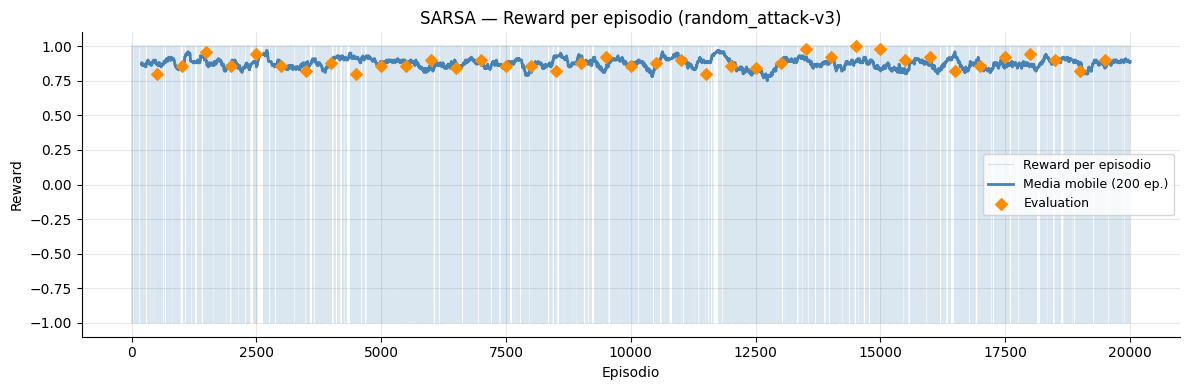

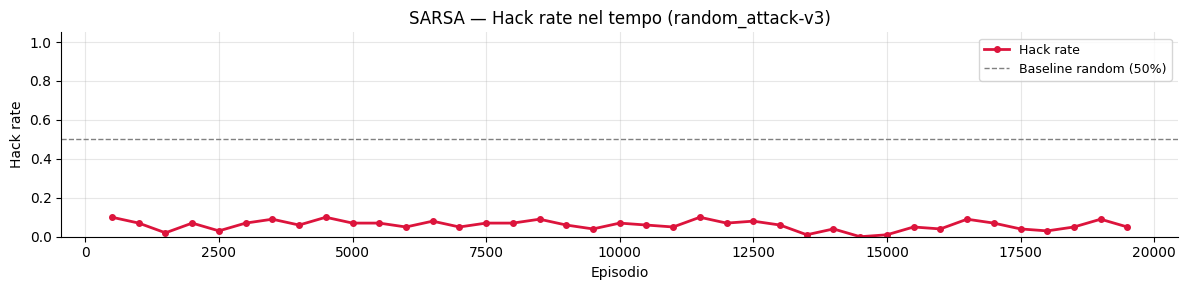

── DDQN su random_attack-v3 ───────────────────────────


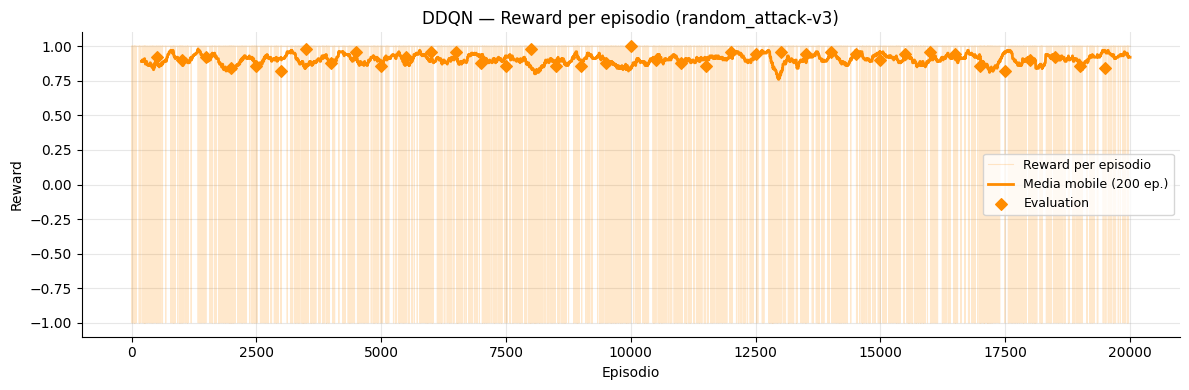

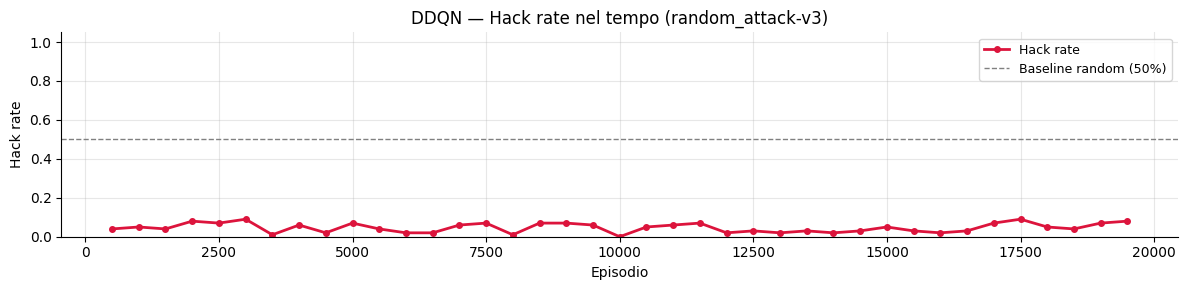

In [23]:
# =============================================================================
# Sezione 4 — Cella 4-D: Visualizzazione risultati v3
# =============================================================================

print('── SARSA su random_attack-v3 ──────────────────────────')
plot_rewards(sarsa_v3_train_r,
             eval_rewards=sarsa_v3_eval_r,
             eval_steps=sarsa_v3_steps,
             title='SARSA — Reward per episodio (random_attack-v3)',
             window=200, color='steelblue')
plot_hack_rate(sarsa_v3_hack, sarsa_v3_steps,
               title='SARSA — Hack rate nel tempo (random_attack-v3)')

print('── DDQN su random_attack-v3 ───────────────────────────')
plot_rewards(ddqn_v3_train_r,
             eval_rewards=ddqn_v3_eval_r,
             eval_steps=ddqn_v3_steps,
             title='DDQN — Reward per episodio (random_attack-v3)',
             window=200, color='darkorange')
plot_hack_rate(ddqn_v3_hack, ddqn_v3_steps,
               title='DDQN — Hack rate nel tempo (random_attack-v3)')

### 4-E  Confronto diretto v0 vs v3 (hack rate + reward)

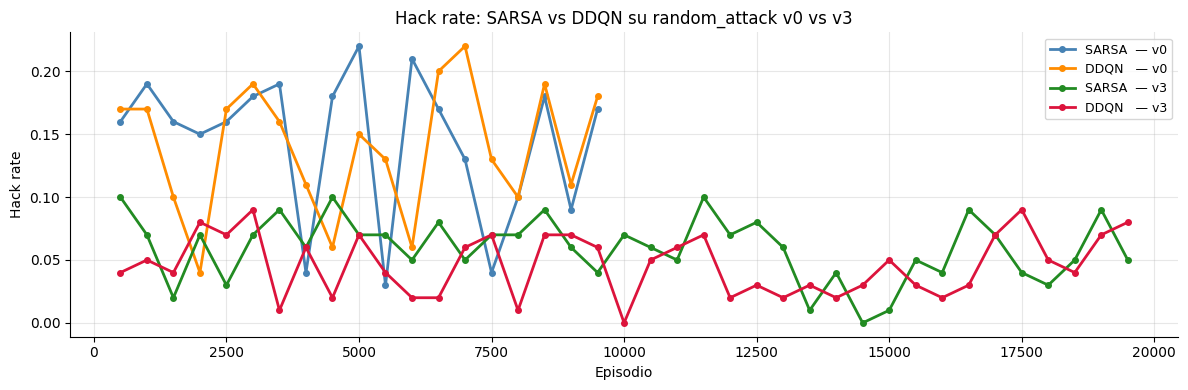

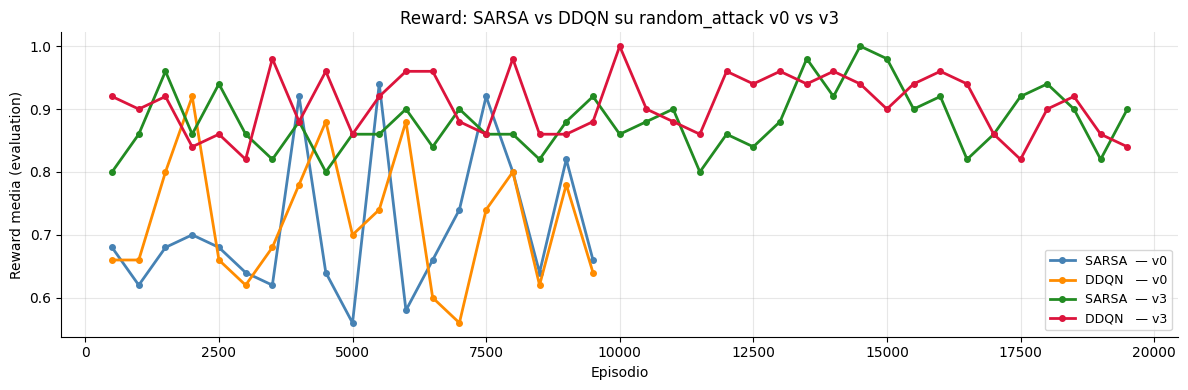

In [24]:
# =============================================================================
# Sezione 4 — Cella 4-E: Confronto diretto v0 vs v3
# =============================================================================
# Questo confronto risponde alla domanda centrale:
# "Come scala la performance degli algoritmi all'aumentare della complessità?"
# SARSA e DDQN vengono confrontati sullo STESSO avversario (random_attack)
# in due configurazioni di rete diverse (v0 vs v3).

# ── Hack rate: tutti e quattro gli scenari ────────────────────────────────────
hack_v0_v3 = {}
if sarsa_eval_steps:  hack_v0_v3['SARSA  — v0'] = (sarsa_eval_steps,  sarsa_hack_rates)
if ddqn_random_steps: hack_v0_v3['DDQN   — v0'] = (ddqn_random_steps, ddqn_random_hack)
if sarsa_v3_steps:    hack_v0_v3['SARSA  — v3'] = (sarsa_v3_steps,    sarsa_v3_hack)
if ddqn_v3_steps:     hack_v0_v3['DDQN   — v3'] = (ddqn_v3_steps,     ddqn_v3_hack)

plot_comparison(
    hack_v0_v3,
    ylabel='Hack rate',
    title='Hack rate: SARSA vs DDQN su random_attack v0 vs v3'
)

# ── Reward evaluation: tutti e quattro gli scenari ───────────────────────────
reward_v0_v3 = {}
if sarsa_eval_steps:  reward_v0_v3['SARSA  — v0'] = (sarsa_eval_steps,  sarsa_eval_r)
if ddqn_random_steps: reward_v0_v3['DDQN   — v0'] = (ddqn_random_steps, ddqn_random_eval_r)
if sarsa_v3_steps:    reward_v0_v3['SARSA  — v3'] = (sarsa_v3_steps,    sarsa_v3_eval_r)
if ddqn_v3_steps:     reward_v0_v3['DDQN   — v3'] = (ddqn_v3_steps,     ddqn_v3_eval_r)

plot_comparison(
    reward_v0_v3,
    ylabel='Reward media (evaluation)',
    title='Reward: SARSA vs DDQN su random_attack v0 vs v3'
)

### 4-F  Report comparativo e analisi effetto complessità

In [25]:
# =============================================================================
# Sezione 4 — Cella 4-F: Report e analisi v0 vs v3
# =============================================================================

print('=' * 70)
print('  REPORT COMPARATIVO — v0 vs v3 (random_attack)')
print('=' * 70)

scenarios = [
    ('SARSA',  'v0', sarsa_eval_r,    sarsa_hack_rates, sarsa_eval_steps),
    ('DDQN',   'v0', ddqn_random_eval_r, ddqn_random_hack, ddqn_random_steps),
    ('SARSA',  'v3', sarsa_v3_eval_r, sarsa_v3_hack,    sarsa_v3_steps),
    ('DDQN',   'v3', ddqn_v3_eval_r,  ddqn_v3_hack,     ddqn_v3_steps),
]

print(f'\n  {"Alg":<8} {"Env":<5} {"Reward iniz.":<14} {"Reward fin.":<13} {"HR iniz.":<10} {"HR fin.":<10} {"Δ HR"}')
print(f'  {"-"*8} {"-"*5} {"-"*14} {"-"*13} {"-"*10} {"-"*10} {"-"*8}')

for alg, ver, ev_r, ev_hr, ev_steps in scenarios:
    if not ev_r:
        print(f'  {alg:<8} {ver:<5} (nessun dato)')
        continue
    r0, rN   = ev_r[0],  ev_r[-1]
    hr0, hrN = ev_hr[0], ev_hr[-1]
    delta_hr = hrN - hr0
    print(f'  {alg:<8} {ver:<5} {r0:<14.3f} {rN:<13.3f} {hr0:<10.3f} {hrN:<10.3f} {delta_hr:>+.3f}')

# ── Q-table v3 vs v0 ─────────────────────────────────────────────────────────
print(f'\n  DIMENSIONE Q-TABLE')
print(f'  SARSA v0 : {len(Q_sarsa):>8,} stati  |  {len(Q_sarsa)*N_ACTIONS*8/1024:.0f} KB')
if 'Q_sarsa_v3' in dir():
    print(f'  SARSA v3 : {len(Q_sarsa_v3):>8,} stati  |  {len(Q_sarsa_v3)*N_ACTIONS_v3*8/1024:.0f} KB')
    ratio = len(Q_sarsa_v3) / max(len(Q_sarsa), 1)
    print(f'  Rapporto : {ratio:.1f}x più stati in v3')

# ── Analisi degenerazione SARSA v3 ───────────────────────────────────────────
if 'Q_sarsa_v3' in dir() and len(Q_sarsa_v3) > 0:
    best_v3 = [int(np.argmax(Q_sarsa_v3[k])) for k in Q_sarsa_v3]
    u3, c3  = np.unique(best_v3, return_counts=True)
    top1_v3 = sorted(zip(c3, u3), reverse=True)[0]
    top1_pct_v3 = 100 * top1_v3[0] / len(Q_sarsa_v3)

    # Fix: zip(counts, unique) mette counts prima -> sorted per FREQUENZA
    # (il vecchio zip(*np.unique) ordinava per valore azione, non per conteggio)
    _best_v0    = [int(np.argmax(Q_sarsa[k])) for k in Q_sarsa]
    _u0, _c0    = np.unique(_best_v0, return_counts=True)
    assert all(0 <= a < N_ACTIONS for a in _u0), "Azione fuori range v0!"
    top1_v0     = sorted(zip(_c0, _u0), reverse=True)[0]   # (count, action)
    top1_pct_v0 = 100 * top1_v0[0] / len(Q_sarsa)

    print(f'\n  DEGENERAZIONE POLICY SARSA (azione dominante)')
    print(f'  v0 : azione {top1_v0[1]:>2d} → {top1_pct_v0:.1f}% degli stati')
    print(f'  v3 : azione {top1_v3[1]:>2d} → {top1_pct_v3:.1f}% degli stati')
    if top1_pct_v3 > top1_pct_v0:
        print(f'  → La policy SARSA è più degenerata su v3: Q-table ancora più sparsa.')
    else:
        print(f'  → Degenerazione simile a v0.')

# ── Interpretazione ──────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('  INTERPRETAZIONE EFFETTO COMPLESSITÀ')
print('=' * 70)
print('''
  Su v3 lo spazio di osservazioni e azioni e' significativamente piu' ampio
  rispetto a v0: piu' nodi, piu' azioni, piu' stati raggiungibili.

  SARSA v0 -> v3:
    Nei nostri esperimenti la Q-table cresce in dimensione, confermando che
    lo spazio viene esplorato piu' ampiamente. La policy SARSA mostra una
    degenerazione verso poche azioni dominanti piu' accentuata su v3,
    coerente con il limite intrinseco degli approcci tabellari al crescere
    della complessita' dello spazio degli stati.

  DDQN v0 -> v3:
    Il DDQN e' teoricamente piu' adatto a spazi di stato ampi grazie alla
    generalizzazione neurale. Il vantaggio effettivo rispetto a SARSA su v3
    va letto nelle metriche osservate: non si puo' assumere automaticamente
    che sia piu' marcato rispetto a v0.

  Considerazione sul dimensionamento:
    v0 e' utile per validare la correttezza implementativa degli algoritmi.
    v3 permette di osservare il comportamento su uno spazio piu' ampio.
    L'impatto sulla difficolta' effettiva della difesa e sull'hack_rate
    e' determinato dai risultati sperimentali, non assunto a priori.
''')
print('=' * 70)
print('  Fine Sezione 4 — Confronto v0 vs v3')
print('=' * 70)

  REPORT COMPARATIVO — v0 vs v3 (random_attack)

  Alg      Env   Reward iniz.   Reward fin.   HR iniz.   HR fin.    Δ HR
  -------- ----- -------------- ------------- ---------- ---------- --------
  SARSA    v0    0.680          0.660         0.160      0.170      +0.010
  DDQN     v0    0.660          0.640         0.170      0.180      +0.010
  SARSA    v3    0.800          0.900         0.100      0.050      -0.050
  DDQN     v3    0.920          0.840         0.040      0.080      +0.040

  DIMENSIONE Q-TABLE
  SARSA v0 :   18,375 stati  |  4307 KB
  SARSA v3 :   57,387 stati  |  35867 KB
  Rapporto : 3.1x più stati in v3

  DEGENERAZIONE POLICY SARSA (azione dominante)
  v0 : azione  0 → 91.4% degli stati
  v3 : azione  0 → 96.0% degli stati
  → La policy SARSA è più degenerata su v3: Q-table ancora più sparsa.

  INTERPRETAZIONE EFFETTO COMPLESSITÀ

  Su v3 lo spazio di osservazioni e azioni e' significativamente piu' ampio
  rispetto a v0: piu' nodi, piu' azioni, piu' stati ra

---

## ✅ Sezione 4 completata

| Scenario | Algoritmo | Env | Metrica chiave |
|---|---|---|---|
| Baseline | SARSA | random_attack-v0 | Reward, hack_rate (calcolo post-fix) |
| Baseline | DDQN  | random_attack-v0 | Reward, hack_rate (calcolo post-fix) |
| Scaling | SARSA | random_attack-v3 | Reward, hack_rate, degenerazione Q-table |
| Scaling | DDQN  | random_attack-v3 | Reward, hack_rate, andamento loss |

Il confronto v0 vs v3 permette di valutare empiricamente l'effetto dell'aumento di complessità sulle metriche dei due algoritmi. Il DDQN è teoricamente avvantaggiato in spazi di stato più ampi grazie alla generalizzazione neurale, ma il vantaggio effettivo rispetto a SARSA va letto nei risultati sperimentali osservati.

---
## ✅ Riepilogo del Progetto

| Algoritmo | Ambiente | Approccio |
|---|---|---|
| SARSA | random_attack | On-policy, Q-table tabellare |
| DDQN | random_attack | Off-policy, rete neurale MLP |
| DDQN | maximal_attack | Off-policy, rete neurale MLP |

### Fix tecnici applicati durante lo sviluppo

| Problema | Causa | Fix |
|---|---|---|
| `gym_idsgame` non trovato | `pip install -e` non aggiorna `sys.path` | `sys.path.insert(0, REPO_PATH)` |
| `np.bool8` mancante | Rimosso in NumPy 2.0 | `np.bool8 = np.bool_` monkey-patch |
| `step()` richiede tupla | API a due agenti | `(0, defender_action)` |
| `reward` è una tupla | Markov Game due agenti | `reward[1]` (defender) |
| Shape obs `(64x33)` vs `(11x128)` | obs reale ≠ dichiarata | `flat_obs()` + `OBS_DIM_FLAT` |
| `hack_rate` sempre 0 | `info['attack_success']` non esposto da gym-idsgame | Calcolo episodio-based: `episode_hacked` se `reward < 0` |
| Azione fuori range nel report SARSA v0 | `zip(*np.unique)` ordinava per valore azione, non frequenza | `zip(counts, unique)` + `assert` su range |